In [1]:
import pandas as pd

route_df = pd.read_csv(r".\recorridos.csv")

route_df['fecha_origen_recorrido'] = pd.to_datetime(route_df['fecha_origen_recorrido'])

df_resumen = route_df.groupby(route_df['fecha_origen_recorrido'].dt.date).size().reset_index(name='cantidad_recorridos')
df_resumen['fecha_origen_recorrido'] = pd.to_datetime(df_resumen['fecha_origen_recorrido'])
df_resumen.set_index('fecha_origen_recorrido', inplace=True)

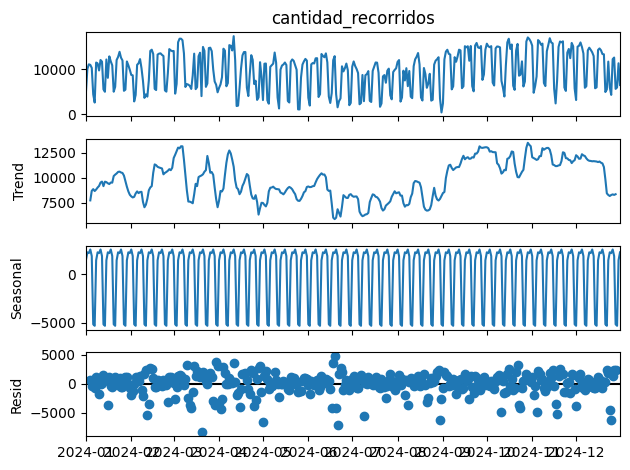

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición (usa 'additive' o 'multiplicative' según el comportamiento de la serie)
decomposition = seasonal_decompose(df_resumen['cantidad_recorridos'], model='additive', period=7)  # Por ejemplo: 7 si esperas estacionalidad semanal

# Plot
decomposition.plot()
plt.tight_layout()
plt.show()

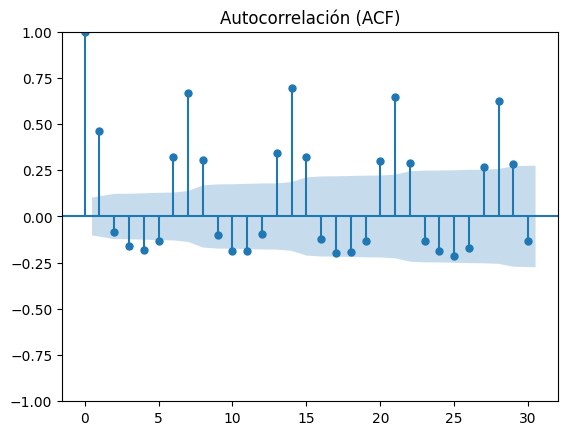

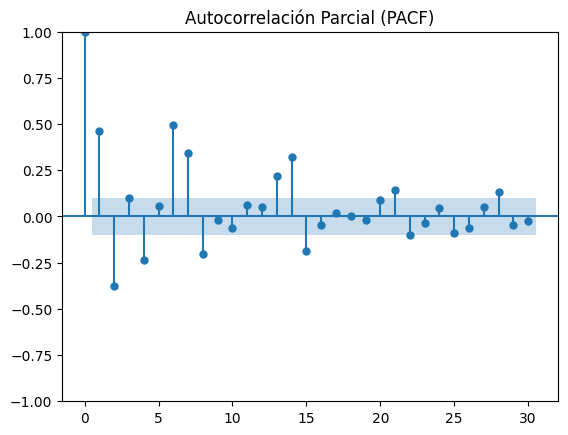

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF muestra correlaciones con lags anteriores
plot_acf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación (ACF)')
plt.show()

# PACF muestra correlaciones parciales (importante para AR terms)
plot_pacf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación Parcial (PACF)')
plt.show()

In [4]:
from statsmodels.stats.diagnostic import acorr_ljungbox

test_result = acorr_ljungbox(df_resumen['cantidad_recorridos'], lags=[7, 14, 21], return_df=True)
print(test_result)

       lb_stat      lb_pvalue
7   315.583544   2.834199e-64
14  615.224208  3.054744e-122
21  894.388725  8.329875e-176


c:\Users\Juan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Juan\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 1977.53, RMSE: 3349.38


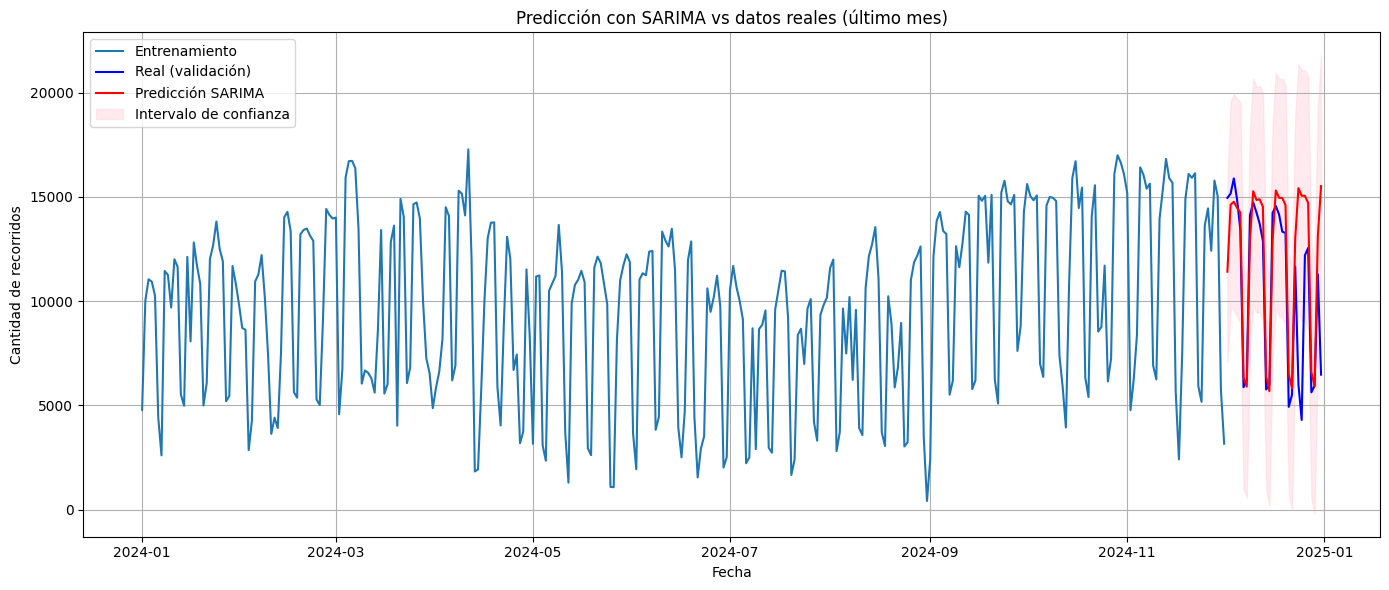

In [7]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Asegurar que el índice es datetime
df_resumen.index = pd.to_datetime(df_resumen.index)

# Separar el último mes (30 días) para validación
n_valid = 30
train = df_resumen.iloc[:-n_valid]
valid = df_resumen.iloc[-n_valid:]

# Entrenar modelo SARIMA con estacionalidad semanal
model = SARIMAX(train['cantidad_recorridos'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

# Predecir sobre el período de validación
forecast = result.get_forecast(steps=n_valid)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluar el modelo
mae = mean_absolute_error(valid['cantidad_recorridos'], forecast_mean)
rmse = np.sqrt(mean_squared_error(valid['cantidad_recorridos'], forecast_mean))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cantidad_recorridos'], label='Entrenamiento')
plt.plot(valid.index, valid['cantidad_recorridos'], label='Real (validación)', color='blue')
plt.plot(valid.index, forecast_mean, label='Predicción SARIMA', color='red')
plt.fill_between(valid.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de confianza')
plt.legend()
plt.title('Predicción con SARIMA vs datos reales (último mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de recorridos')
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
from xgboost import XGBRegressor

# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'xgboost'